In [1]:
import keras

In [2]:
from keras import layers

In [4]:
lenet5 = keras.Sequential()
lenet5.add(layers.Input(shape=(28,28,1)))
lenet5.add(layers.Conv2D(filters=6, kernel_size=5, activation='sigmoid', padding='same'))
lenet5.add(layers.AveragePooling2D(2))
lenet5.add(layers.Conv2D(filters=16, kernel_size=5, activation='sigmoid'))
lenet5.add(layers.AveragePooling2D(2))
lenet5.add(layers.Flatten())
lenet5.add(layers.Dense(120, activation='sigmoid'))
lenet5.add(layers.Dense(84, activation='sigmoid'))
lenet5.add(layers.Dense(10, activation='softmax'))

lenet5.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
(train_input, train_target),(test_input, test_target) = \
keras.datasets.fashion_mnist.load_data()

In [6]:
print(train_target)

[9 0 0 ... 3 0 5]


In [7]:
print(train_input.shape, train_target.shape)

(60000, 28, 28) (60000,)


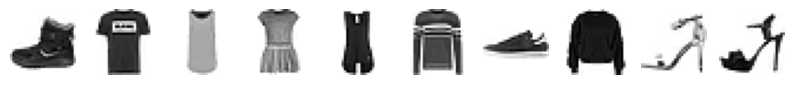

In [9]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1,10, figsize=(10,10))
for i in range(10):
    axs[i].imshow(train_input[i], cmap='gray_r')
    axs[i].axis('off')
plt.show()

In [10]:
train_input = train_input.reshape(-1, 28, 28, 1) / 255.0

In [11]:
from sklearn.model_selection import train_test_split

train_scaled, val_scaled, train_target, val_target = train_test_split( \
train_input, train_target, test_size=0.2, random_state=42)

In [12]:
checkpoint_cb = keras.callbacks.ModelCheckpoint('lenet5-model.keras', save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)

In [13]:
lenet5.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
hist = lenet5.fit(train_scaled, train_target, epochs=50, validation_data=(val_scaled,\
        val_target), callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6039 - loss: 1.0636 - val_accuracy: 0.7110 - val_loss: 0.7253
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7483 - loss: 0.6475 - val_accuracy: 0.7504 - val_loss: 0.6103
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7795 - loss: 0.5748 - val_accuracy: 0.7915 - val_loss: 0.5501
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8042 - loss: 0.5195 - val_accuracy: 0.7847 - val_loss: 0.5476
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8216 - loss: 0.4769 - val_accuracy: 0.8241 - val_loss: 0.4747
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8340 - loss: 0.4472 - val_accuracy: 0.8346 - val_loss: 0.4446
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8438 - loss: 0.4240 - val_accuracy: 0.8313 - val_loss: 0.4541
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8497 - loss: 0.4063 - 

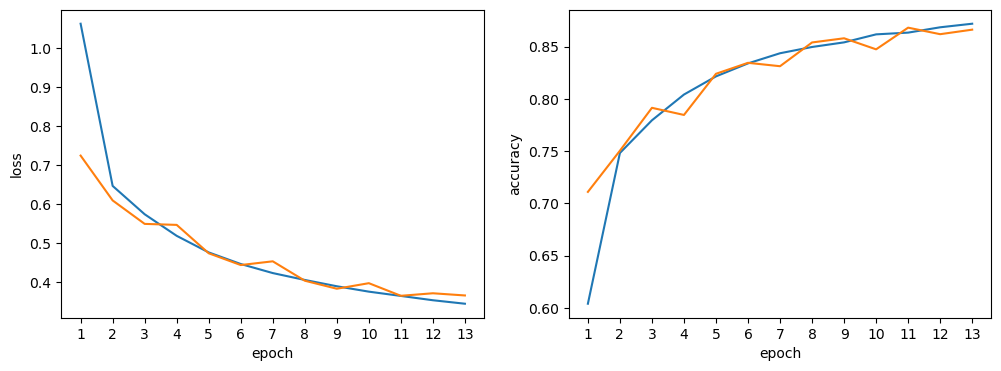

In [14]:
epoches = range(1, len(hist.history['loss'])+1)

fig, axs = plt.subplots(1,2, figsize=(12,4))
axs[0].plot(epoches, hist.history['loss'])
axs[0].plot(epoches, hist.history['val_loss'])
axs[0].set_xticks(epoches)
axs[0].set_xlabel('epoch')
axs[0].set_ylabel('loss')
axs[1].plot(epoches, hist.history['accuracy'])
axs[1].plot(epoches, hist.history['val_accuracy'])
axs[1].set_xticks(epoches)
axs[1].set_xlabel('epoch')
axs[1].set_ylabel('accuracy')
plt.show()